<a href="https://colab.research.google.com/github/bugristaya/comp_ling/blob/main/bykova_rnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **RNN/LSTM**

Цель семинара: получить практический опыт работы с RNN (LSTM) в PyTorch на задачах генерации последовательностей

Мы разберем полный пайплайн разработки от препроцессинга данных до обучения и экспериментов с гиперпараметрами

Кстати, что мы называем **пайплайном**?

В Google Colab (рекомендуется активировать GPU: `Среда выполнения → Сменить среду выполнения → T4 GPU`)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

## **ЧАСТЬ 1: ДЕМО**
*   **Задача модели:** предсказание случайного временного ряда (синусоида)
*   **Цель демонстрации:** показать полный и минимальный рабочий пайплайн RNN на задаче, связанной с обработкой данных, передающих изменения во времени
*   **План:**
    1.  Подготовка последовательностей (sequences)
    2.  Архитектура `nn.LSTM`
    3.  Обучение модели
    4.  Получение метрик оценки
    5.  Визуализация и интерпретация результата

### 1. ГЕНЕРАЦИЯ И ПОДГОТОВКА ДАННЫХ

In [ ]:
def generate_sine_wave(seq_length=1000, periods=5):
    """Генерация синусоиды."""
    x = np.linspace(0, periods * 2 * np.pi, seq_length)
    y = np.sin(x)
    return y

# Генерация данных
data = generate_sine_wave()
print(f"Длина временного ряда: {len(data)}")

Длина временного ряда: 1000


In [ ]:
# Параметры последовательностей
SEQ_LEN = 50  # Длина входной последовательности для предсказания
BATCH_SIZE = 16

In [ ]:
def create_sequences(data, seq_len):
    """Создание пар (входная последовательность, целевое значение)."""
    sequences = []
    targets = []
    for i in range(len(data) - seq_len - 1):
        seq = data[i:i + seq_len]
        target = data[i + seq_len]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

In [ ]:
# Создание последовательностей
X, y = create_sequences(data, SEQ_LEN)
print(f"Форма X (последовательности): {X.shape}")
print(f"Форма y (цели): {y.shape}")

Форма X (последовательности): (949, 50)
Форма y (цели): (949,)


In [ ]:
# Преобразование в тензоры PyTorch и добавление размерности для признаков
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # [примеры, SEQ_LEN, 1]
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)  # [примеры, 1]
print(f"Форма X (тензор): {X.shape}")
print(f"Форма y (тензор): {y.shape}")

Форма X (тензор): torch.Size([949, 50, 1])
Форма y (тензор): torch.Size([949, 1])


In [ ]:
# Разделение на обучающую и тестовую выборки
split_idx = int(0.8 * len(X))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

In [ ]:
### 2. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM
class SineLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True  # формат [batch, seq_len, features]
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Инициализация скрытого состояния и состояния ячейки
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)

        # Прямой проход через LSTM
        out, _ = self.lstm(x, (h0, c0))

        # Берем только последний выход последовательности для предсказания
        out = self.fc(out[:, -1, :])
        return out

In [ ]:
# Инициализация модели
model = SineLSTM()
print(f"Модель:\n{model}")

Модель:
SineLSTM(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


### 3. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
# Гиперпараметры
EPOCHS = 20
LEARNING_RATE = 0.01

# Функция потерь и оптимизатор
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Тренировочный цикл
train_losses = []
test_losses = []

for epoch in range(EPOCHS):
    model.train()

    # Прямой проход
    predictions = model(X_train)
    loss = criterion(predictions, y_train)

    # Обратное распространение
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Оценка на тестовой выборке
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test)
        test_loss = criterion(test_predictions, y_test)
        test_losses.append(test_loss.item())

    if (epoch + 1) % 5 == 0:
        print(f'Эпоха [{epoch+1}/{EPOCHS}], '
              f'Ошибка обучения: {loss.item():.6f}, '
              f'Ошибка теста: {test_loss.item():.6f}')

Эпоха [5/20], Ошибка обучения: 0.435332, Ошибка теста: 0.138063
Эпоха [10/20], Ошибка обучения: 0.124452, Ошибка теста: 0.124109
Эпоха [15/20], Ошибка обучения: 0.022266, Ошибка теста: 0.026756
Эпоха [20/20], Ошибка обучения: 0.029354, Ошибка теста: 0.017334


### 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ

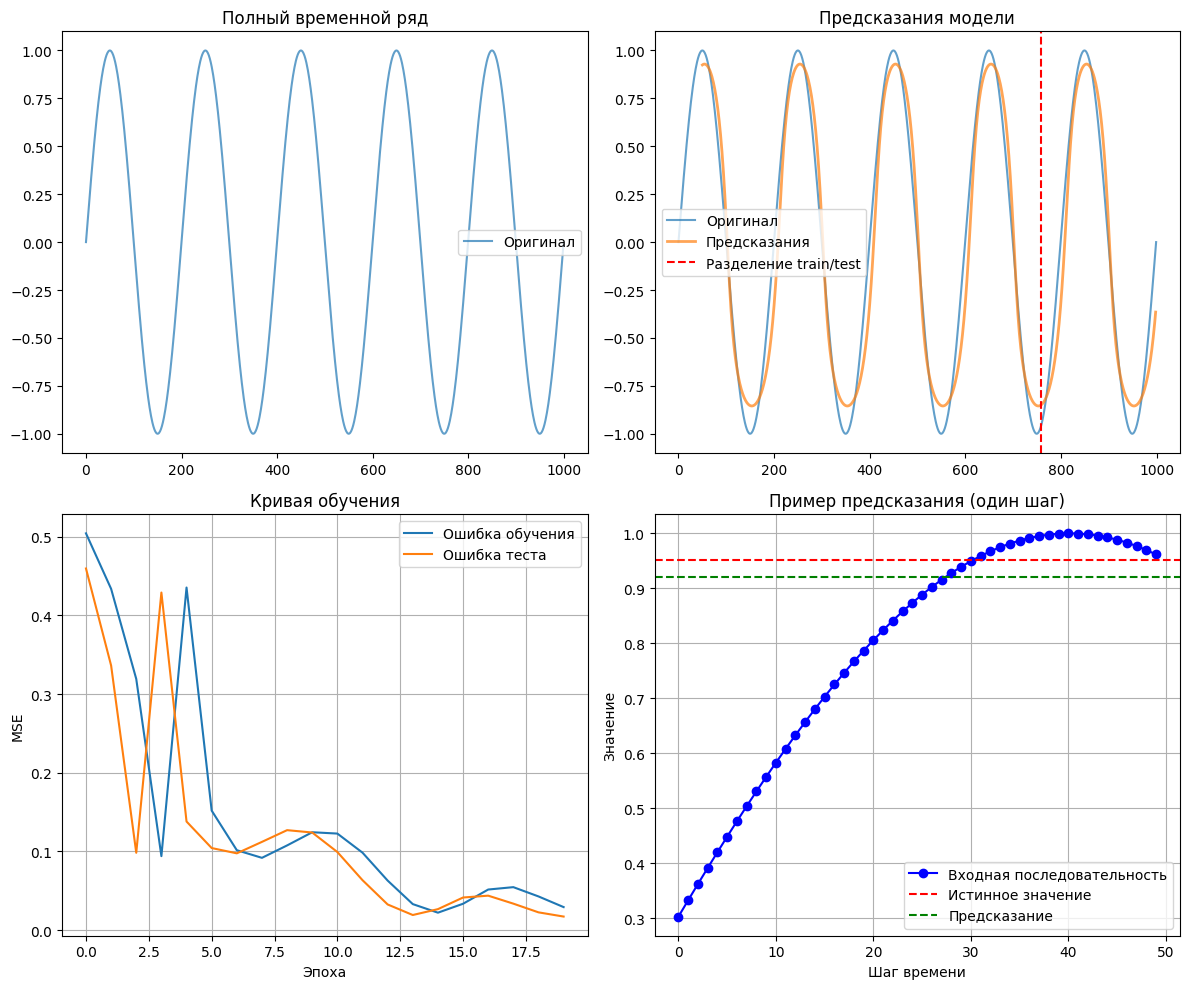

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# График 1: Оригинальные данные и предсказания
axes[0, 0].plot(data, label='Оригинал', alpha=0.7)
axes[0, 0].set_title('Полный временной ряд')
axes[0, 0].legend()

# График 2: Предсказания на тестовой выборке
model.eval()
with torch.no_grad():
    all_predictions = model(X).numpy()

# Создание массива для отображения предсказаний
pred_series = np.full_like(data, np.nan)
pred_series[SEQ_LEN:SEQ_LEN + len(all_predictions)] = all_predictions.squeeze()

axes[0, 1].plot(data, label='Оригинал', alpha=0.7)
axes[0, 1].plot(pred_series, label='Предсказания', alpha=0.7, linewidth=2)
axes[0, 1].axvline(x=split_idx, color='r', linestyle='--', label='Разделение train/test')
axes[0, 1].set_title('Предсказания модели')
axes[0, 1].legend()

# График 3: Ошибки обучения и теста
axes[1, 0].plot(train_losses, label='Ошибка обучения')
axes[1, 0].plot(test_losses, label='Ошибка теста')
axes[1, 0].set_xlabel('Эпоха')
axes[1, 0].set_ylabel('MSE')
axes[1, 0].set_title('Кривая обучения')
axes[1, 0].legend()
axes[1, 0].grid(True)

# График 4: Пример одного предсказания
sample_idx = split_idx + 50
axes[1, 1].plot(range(SEQ_LEN), X[sample_idx].squeeze().numpy(),
                'bo-', label='Входная последовательность')
axes[1, 1].axhline(y=y[sample_idx].item(), color='r', linestyle='--',
                   label='Истинное значение')
axes[1, 1].axhline(y=all_predictions[sample_idx].item(), color='g',
                   linestyle='--', label='Предсказание')
axes[1, 1].set_xlabel('Шаг времени')
axes[1, 1].set_ylabel('Значение')
axes[1, 1].set_title('Пример предсказания (один шаг)')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

### 5. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
1. Кривая обучения должна снижаться на обеих выборках
2. Предсказания должны следовать за оригинальным рядом
3. Разрыв между train/test loss указывает на переобучение
4. Модель учится предсказывать следующий шаг синусоиды

Take aways:

1. Подготовка последовательностей: как из временного ряда создаются пары (окно истории -> целевое значение)?

2. Архитектура LSTM: batch_first=True, почему берем out[:, -1, :]

3. Цикл обучения: разделение на model.train() и model.eval(), логика .zero_grad(), .backward(), .step()

4. Визуализация: как интерпретировать каждый из 4-х графиков?

---

# ПРАКТИКА

1. ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНЫЙ ПРОСМОТР ДАННЫХ

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import reuters

https://www.tensorflow.org/api_docs/python/tf/keras/datasets/reuters/load_data

In [ ]:
# TODO 1.1: Загрузите датасет Reuters
(x_train, y_train), (x_test, y_test) = reuters.load_data()

# TODO 1.2: Изучите структуру данных
print("Тип x_train:", type(x_train))
print("Длина x_train:", len(x_train))
print("Первая последовательность (первые 10 индексов):", x_train[0][:10])
print("Длина первой последовательности:", len(x_train[0]))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Тип x_train: <class 'numpy.ndarray'>
Длина x_train: 8982
Первая последовательность (первые 10 индексов): [1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207]
Длина первой последовательности: 87


2. ПОДГОТОВКА СЛОВАРЯ И ДЕКОДИРОВАНИЕ

In [ ]:
# TODO 2.1: Загрузите словарь слов
word_index = reuters.get_word_index()
reverse_word_index = {value: key for (key, value) in word_index.items()}

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step


In [ ]:
# TODO 2.2: Реализуйте функцию декодирования последовательности
def decode_sequence(sequence):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in sequence])

first_article = decode_sequence(x_train[0])
print("\nПервая статья (первые 200 символов):", first_article[:200])


Первая статья (первые 200 символов): ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net shou


3. ПОДГОТОВКА ДАННЫХ ДЛЯ ГЕНЕРАЦИИ ТЕКСТА

In [ ]:
# TODO 3.1: Объедините первые 1000 статей в один текст
max_articles = 1000
max_articles_idx = x_train[:max_articles]
max_articles_texts = [decode_sequence(seq) for seq in max_articles_idx]
texts = ' '.join(max_articles_texts)

print(f"Общая длина текста (символов): {len(texts)}")
print("Пример текста:", texts[:500])

Общая длина текста (символов): 815340
Пример текста: ? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3 ? generale de banque sa lt genb br and lt heller overseas corp of chicago have each taken 50 pct 


In [ ]:
# TODO 3.2: Создайте словари для преобразования символов в индексы и обратно
chars = sorted(list(set(texts)))
print(chars)

[' ', "'", '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '?', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [ ]:
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

vocab_size = len(chars)
print(f"Размер словаря (уникальных символов): {vocab_size}")

Размер словаря (уникальных символов): 39


In [ ]:
idx_to_char

{0: ' ',
 1: "'",
 2: '0',
 3: '1',
 4: '2',
 5: '3',
 6: '4',
 7: '5',
 8: '6',
 9: '7',
 10: '8',
 11: '9',
 12: '?',
 13: 'a',
 14: 'b',
 15: 'c',
 16: 'd',
 17: 'e',
 18: 'f',
 19: 'g',
 20: 'h',
 21: 'i',
 22: 'j',
 23: 'k',
 24: 'l',
 25: 'm',
 26: 'n',
 27: 'o',
 28: 'p',
 29: 'q',
 30: 'r',
 31: 's',
 32: 't',
 33: 'u',
 34: 'v',
 35: 'w',
 36: 'x',
 37: 'y',
 38: 'z'}

In [ ]:
# TODO 3.3: Преобразуйте текст в последовательность индексов
text_as_int = [char_to_idx[ch] for ch in texts]
texts[:10], text_as_int[:10]

('? mcgrath ', [12, 0, 25, 15, 19, 30, 13, 32, 20, 0])

In [ ]:
text_as_int = np.array(text_as_int)

text_as_int

array([12,  0, 25, ..., 30,  0,  5])

4. ФОРМИРОВАНИЕ ПРОМПТОВ И ОТВЕТОВ

In [ ]:
seq_length = 100

In [ ]:
# TODO 4.1: Реализуйте функцию create_sequences для создания обучающих примеров
def create_sequences(text_indices, seq_len):
    input_seq = []
    target_seq = []

    for i in range(len(text_indices)-seq_len):
        current_x_seq = text_indices[i:i+seq_len]
        input_seq.append(current_x_seq)

        current_y_seq = text_indices[i+seq_len]
        target_seq.append(current_y_seq)

    return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)

input_seq, target_seq = create_sequences(text_as_int, seq_length)

/tmp/ipython-input-1110/2203781802.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  return torch.tensor(input_seq, dtype=torch.long), torch.tensor(target_seq, dtype=torch.long)


In [ ]:
input_seq

tensor([[12,  0, 25,  ..., 17, 30,  0],
        [ 0, 25, 15,  ..., 30,  0, 31],
        [25, 15, 19,  ...,  0, 31, 20],
        ...,
        [26, 21, 26,  ..., 33, 32, 17],
        [21, 26, 17,  ..., 32, 17, 30],
        [26, 17,  0,  ..., 17, 30,  0]])

In [ ]:
target_seq

tensor([31, 20, 13,  ..., 30,  0,  5])

In [ ]:
print(f"Количество примеров: {len(input_seq)}")
print(f"Форма input_seq: {input_seq.shape}")
print(f"Форма target_seq: {target_seq.shape}")

Количество примеров: 815240
Форма input_seq: torch.Size([815240, 100])
Форма target_seq: torch.Size([815240])


In [ ]:
# TODO 4.2: Создайте DataLoader для пакетной обработки
batch_size = 32
dataset = torch.utils.data.TensorDataset(input_seq, target_seq)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [ ]:
dataset

In [ ]:
dataloader

5. ОПРЕДЕЛЕНИЕ МОДЕЛИ LSTM

In [ ]:
class CharLSTM(nn.Module):
    def __init__(self, vocab_size, hidden_size=128, num_layers=2, embedding_dim=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # TODO 5.1: Определите слои модели
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        # TODO 5.2: Реализуйте forward pass
        # Шаг 1: Примените слой эмбеддинга
        embedded = self.embedding(x)

        # Шаг 2: Прямой проход через LSTM
        if hidden is None:
            lstm_out, hidden = self.lstm(embedded)
        else:
            lstm_out, hidden = self.lstm(embedded, hidden)

        # Шаг 3: Возьмите только последний выход LSTM
        lstm_out = lstm_out[:, -1, :]

        # Шаг 4: Примените полносвязный слой
        output = self.fc(lstm_out)

        return output, hidden

device = torch.device('cuda')

# TODO 5.3: Инициализируйте модель
model = CharLSTM(vocab_size=vocab_size, hidden_size=128, num_layers=2)
model = model.to(device)
print(f"\nМодель:\n{model}")


Модель:
CharLSTM(
  (embedding): Embedding(39, 64)
  (lstm): LSTM(64, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=39, bias=True)
)


6. ОБУЧЕНИЕ МОДЕЛИ

In [ ]:
EPOCHS = 4
LEARNING_RATE = 0.005

In [ ]:
# TODO 6.1: Определите функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
# Функция для генерации текста
def generate_text(model, seed_text, length=100, temperature=1.0):
    """Генерация текста на основе начальной последовательности."""
    model.eval()
    generated = seed_text

    # Преобразуем seed в индексы, фильтруя символы, которых нет в словаре
    seed_indices = []
    for ch in seed_text:
        if ch in char_to_idx:
            seed_indices.append(char_to_idx[ch])
        else:
            # Если символа нет в словаре, используем первый попавшийся символ
            seed_indices.append(0)

    if len(seed_indices) == 0:
        seed_indices = [0]  # На случай пустого seed

    with torch.no_grad():
        # Создаем начальное hidden state
        batch_size = 1
        h0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        c0 = torch.zeros(model.num_layers, batch_size, model.hidden_size).to(device)
        hidden = (h0, c0)

        # "Прогреваем" модель на seed последовательности
        for i in range(len(seed_indices) - 1):
            input_tensor = torch.tensor([[seed_indices[i]]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        # Начинаем генерацию
        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)

            # Применяем temperature для управления случайностью
            output = output / temperature
            probabilities = torch.softmax(output, dim=-1)

            # Выбираем следующий символ на основе вероятностей
            next_char_idx = torch.multinomial(probabilities, 1).item()

            # Добавляем символ к сгенерированному тексту
            generated += idx_to_char[next_char_idx]

            # Обновляем вход для следующей итерации
            current_input = torch.tensor([[next_char_idx]], dtype=torch.long).to(device)

    return generated

# Тренировочный цикл
train_losses = []

print("\nНачало обучения...")
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    batch_count = len(dataloader)

    for batch_idx, (batch_input, batch_target) in enumerate(dataloader):
        # Перемещаем данные на GPU
        batch_input = batch_input.to(device)
        batch_target = batch_target.to(device)

        optimizer.zero_grad()

        # Прямой проход
        output, _ = model(batch_input)
        loss = criterion(output, batch_target)

        # Обратное распространение
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

        # Логгирование прогресса каждые 50 батчей
        if (batch_idx + 1) % 50 == 0:
            avg_batch_loss = loss.item()
            print(f'Эпоха [{epoch+1}/{EPOCHS}], Батч [{batch_idx+1}/{batch_count}], Потеря: {avg_batch_loss:.4f}')

    avg_loss = total_loss / len(dataloader)
    train_losses.append(avg_loss)

    # Генерация текста для мониторинга прогресса
    if (epoch + 1) % 2 == 0:
        # Используем seed текст, который точно есть в нашем словаре
        # Преобразуем к нижнему регистру, чтобы гарантировать наличие символов
        seed = "the company said"
        # Альтернативно: можно проверить, какие символы есть в словаре
        safe_seed = ''.join([ch for ch in seed if ch in char_to_idx])
        if len(safe_seed) > 0:
            generated = generate_text(model, safe_seed, length=50, temperature=0.8)
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print(f'Сгенерированный текст: "{generated}"')
        else:
            print(f'\nЭпоха [{epoch+1}/{EPOCHS}], Средняя ошибка: {avg_loss:.4f}')
            print('Не удалось сгенерировать текст: seed содержит неизвестные символы')


Начало обучения...
Эпоха [1/4], Батч [50/25477], Потеря: 2.7288
Эпоха [1/4], Батч [100/25477], Потеря: 2.7619
Эпоха [1/4], Батч [150/25477], Потеря: 2.3571
Эпоха [1/4], Батч [200/25477], Потеря: 2.3874
Эпоха [1/4], Батч [250/25477], Потеря: 1.6960
Эпоха [1/4], Батч [300/25477], Потеря: 2.2800
Эпоха [1/4], Батч [350/25477], Потеря: 2.1668
Эпоха [1/4], Батч [400/25477], Потеря: 1.9963
Эпоха [1/4], Батч [450/25477], Потеря: 2.0919
Эпоха [1/4], Батч [500/25477], Потеря: 2.0021
Эпоха [1/4], Батч [550/25477], Потеря: 2.1459
Эпоха [1/4], Батч [600/25477], Потеря: 1.7163
Эпоха [1/4], Батч [650/25477], Потеря: 2.4897
Эпоха [1/4], Батч [700/25477], Потеря: 2.2191
Эпоха [1/4], Батч [750/25477], Потеря: 1.7786
Эпоха [1/4], Батч [800/25477], Потеря: 2.0750
Эпоха [1/4], Батч [850/25477], Потеря: 1.8792
Эпоха [1/4], Батч [900/25477], Потеря: 2.0568
Эпоха [1/4], Батч [950/25477], Потеря: 2.3912
Эпоха [1/4], Батч [1000/25477], Потеря: 1.9833
Эпоха [1/4], Батч [1050/25477], Потеря: 2.0768
Эпоха [1/4], 

---

# ДОМАШНЕЕ ЗАДАНИЕ (дедлайн: 28 февраля, 23.59)

**Задача:** обучить модель с разными гиперпараметрами

1. Набор A: hidden_size=64, num_layers=1, learning_rate=0.01

2. Набор B: hidden_size=256, num_layers=2, learning_rate=0.001

3. Набор C: любой произвольный набор параметров hidden_size, num_layers, learning_rate, отличный от предложенных

Сравните:

- Скорость сходимости (график loss)
- Качество генерации (осмысленность текста)
- Время обучения

In [ ]:
# Исправленная функция генерации текста
def generate_text_fixed(model, seed_text, length=100, temperature=0.8):
    """Генерирует текст, начиная с seed_text."""
    model.eval()
    generated = seed_text

    seed_indices = [char_to_idx[ch] for ch in seed_text if ch in char_to_idx]
    if not seed_indices:
        seed_indices = [0]

    with torch.no_grad():
        hidden = None
        for idx in seed_indices:
            input_tensor = torch.tensor([[idx]], dtype=torch.long).to(device)
            _, hidden = model(input_tensor, hidden)

        current_input = torch.tensor([[seed_indices[-1]]], dtype=torch.long).to(device)

        for _ in range(length):
            output, hidden = model(current_input, hidden)
            output = output / temperature
            probs = torch.softmax(output, dim=-1)
            next_idx = torch.multinomial(probs.squeeze(), 1).item()
            generated += idx_to_char[next_idx]
            current_input = torch.tensor([[next_idx]], dtype=torch.long).to(device)

    return generated

In [ ]:
import time

configs = [
    {'name': 'A', 'hidden': 64,  'layers': 1, 'lr': 0.01},
    {'name': 'B', 'hidden': 256, 'layers': 2, 'lr': 0.001},
    {'name': 'C', 'hidden': 128, 'layers': 3, 'lr': 0.005}
]

results = {}

EPOCHS = 4

for cfg in configs:
    print(f"Обучение {cfg['name']}: "
          f"hidden={cfg['hidden']}, layers={cfg['layers']}, lr={cfg['lr']}")


    model = CharLSTM(vocab_size=vocab_size,
                     hidden_size=cfg['hidden'],
                     num_layers=cfg['layers']).to(device)
    optimizer = optim.Adam(model.parameters(), lr=cfg['lr'])

    losses = []
    start_time = time.time()

    for epoch in range(1, EPOCHS+1):
        model.train()
        total_loss = 0.0
        for batch_input, batch_target in dataloader:
            batch_input = batch_input.to(device)
            batch_target = batch_target.to(device)

            optimizer.zero_grad()
            output, _ = model(batch_input)
            loss = criterion(output, batch_target)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        losses.append(avg_loss)
        print(f"Эпоха {epoch}/{EPOCHS}, Loss: {avg_loss:.4f}")

    elapsed = time.time() - start_time

    seed = "the company "
    generated = generate_text_fixed(model, seed, length=100, temperature=0.8)

    results[cfg['name']] = {
        'losses': losses,
        'time': elapsed,
        'generated': generated,
        'params': cfg
    }



Обучение A: hidden=64, layers=1, lr=0.01
Эпоха 1/4, Loss: 1.8886
Эпоха 2/4, Loss: 1.8212
Эпоха 3/4, Loss: 1.8298
Эпоха 4/4, Loss: 1.8181
Обучение B: hidden=256, layers=2, lr=0.001
Эпоха 1/4, Loss: 1.4646
Эпоха 2/4, Loss: 1.2525
Эпоха 3/4, Loss: 1.2112
Эпоха 4/4, Loss: 1.1945
Обучение C: hidden=128, layers=3, lr=0.005
Эпоха 1/4, Loss: 1.6509
Эпоха 2/4, Loss: 1.5518
Эпоха 3/4, Loss: 1.5486
Эпоха 4/4, Loss: 1.5531


In [ ]:
for name, data in results.items():
    print(f"Модель: {name}")
    print(f"  Потери (losses): {data['losses']}")
    print(f"  Время (time): {data['time']:.2f} сек")
    print(f"  Сгенерировано (generated): {data['generated']}")
    print(f"  Параметры (params): {data['params']}")

Модель: A
  Потери (losses): [1.8886244651398807, 1.8212314715082045, 1.8297957061935164, 1.8180962821895166]
  Время (time): 360.21 сек
  Сгенерировано (generated): the company new to acting and revious that tae sec'an privis was ofsit by expect incurs and company resed has li
  Параметры (params): {'name': 'A', 'hidden': 64, 'layers': 1, 'lr': 0.01}
Модель: B
  Потери (losses): [1.4645550886872623, 1.2525291270118926, 1.2111554647505496, 1.1944732074355828]
  Время (time): 1110.89 сек
  Сгенерировано (generated): the company offered at a gains to the preculited a rustill rumours issued or gilber buyers with buying specializ
  Параметры (params): {'name': 'B', 'hidden': 256, 'layers': 2, 'lr': 0.001}
Модель: C
  Потери (losses): [1.650877446360831, 1.551780747238244, 1.5486473196243553, 1.5531021262415865]
  Время (time): 388.08 сек
  Сгенерировано (generated): the company the hire to u s scome total loss comporal justed adding a branch pps market average governing is a c
  Параметры 

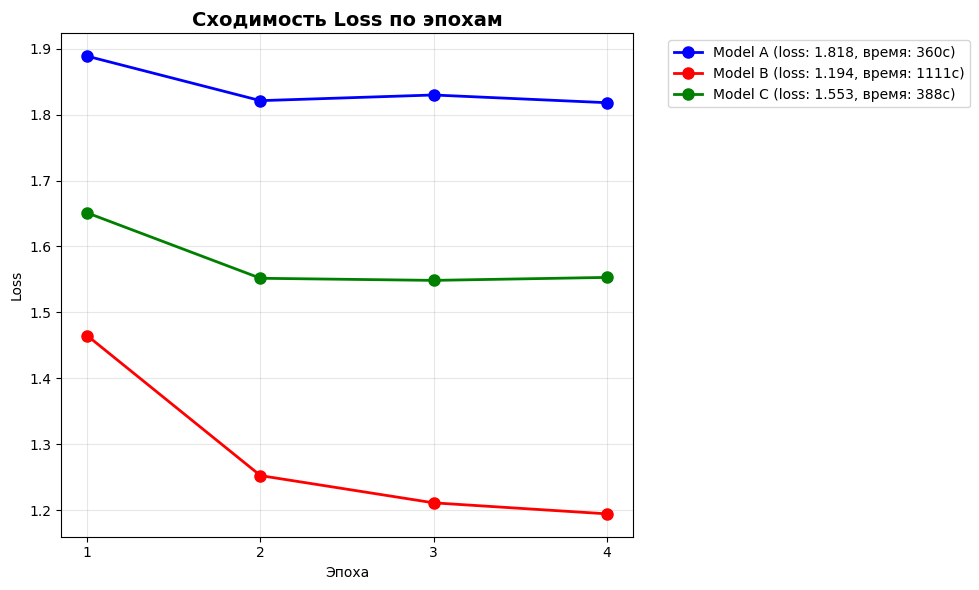

In [ ]:
# создание визуализаций
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(1, 5)
colors = {'A': 'blue', 'B': 'red', 'C': 'green'}

plt.figure(figsize=(10, 6))

for name, data in configs.items():
    plt.plot(epochs, data['losses'],
             marker='o',
             color=colors[name],
             linewidth=2,
             markersize=8,
             label=f'Model {name} (loss: {data["losses"][-1]:.3f}, время: {data["time"]:.0f}c)')

plt.title('Сходимость Loss по эпохам', fontsize=14, fontweight='bold')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xticks(epochs)
plt.tight_layout()
plt.show()


Сравние:

1. Скорость сходимости (график loss)

У модели A потери снижаются незначительно, а также наблюдается небольшое колебание. Сходимость слабая, модель практически не улучшается после первой эпохи.

У модели B потери быстро падают, лостигая минимального значения к четвёртой эпохе достигается минимальное значение.

У модели C потери незначительно снижаются и почти не меняются после второй эпохи


2. Качество генерации (осмысленность текста)

А: the company new to acting and revious that tae sec'an privis was ofsit by expect incurs and company resed has li

В: the company offered at a gains to the preculited a rustill rumours issued or gilber buyers with buying specializ

С: the company the hire to u s scome total loss comporal justed adding a branch pps market average governing is a c

Наилучший вариант - В, однако он остается достаточно грамматически несвязным. В С и А появялются несуществующие слова и просто буквы

3. Время обучения

А: 360.21 сек

В: 1110.89 сек

С: 388.08 сек

Модель В обучалась дольше всех, потому что размер скрытого слоя является самым большим среди всех моделей











### **ВОПРОСЫ ДЛЯ РЕФЛЕКСИИ**

1.  Какие ключевые отличия вы заметили в подготовке данных для числового ряда (синусоида) и текста?

С синусоудой проще работать, потому что при работе с дискетными данными не требуется работы со словарем. Также среднеквалратичная ошибка используется для работы с числовым рядом

2.  Какой опыт работы с PyTorch (например, отладка, подбор параметров) оказался самым полезным?

Наиболее полезным мне показался опыт настройки гиперпараметров и отладки размерностей тензоров